# Linescan Imaging (LSIMG)

In [1]:
# force Jupyter to autoreload modules when they have been edited
# this helps keep the iodp module current as it is actively developed.
%load_ext autoreload
%autoreload 2

In [40]:
import sys
import os
from importlib import reload
import ast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from iodp import utils, img




In [5]:
# Ensure we are in the PhysicalProperties root folder
if not os.getcwd().endswith("Imaging"):
    print("Current working directory:", os.getcwd())
    os.chdir("../")
    
print("New current working directory:", os.getcwd())

New current working directory: d:\archive\hd_files\data_analysis\50_laboratory_notebooks\SOD-Laboratory\Imaging


## Reading LSIMG .ini files

In [9]:
file = './data/input/i_pi_ajai-cv-l107cl.ini'
df = utils.read_instrument_ini(file, as_dataframe=True)
df

,value
key,
mgi rwa section options,2.0.1 %04Y%02m%02d %02H%02M%S%25u*~|.%d*~|....
ims framework-major,13
ims framework-minor,0
plugin-major,0
plugin-minor,0
...,...
ar700.error.source,
ar700.scan,Status=Idle
ims abort visible?,FALSE


## Reading LSIMG .roi files

In [28]:
file = './data/input/402-U1612A-16R-1-A_SHLF13017601_20240216235612.roi'
df = utils.read_instrument_file(file, as_dataframe=False)
df

{'datetime': '2024-02-16 23:56:12 UTC',
 'labelid': '402-U1612A-16R-1-A',
 'user': 'JR_MARONE',
 'text_id': 'SHLF13017601',
 'instrument': '0) JAI MODEL: SW-2001T-CL-F S/N: L200725A, 1)  MODEL:  S/N:',
 'instrument_group': 'SHIL',
 'observed_length': '150.00',
 'comment': '',
 'display': 'T',
 'image_purpose': 'Soft Sediment',
 'image_description': 'Pristine',
 'roi_upper_edge': '5',
 'roi_lower_edge': '31276',
 'roi_left_edge': '384',
 'roi_right_edge': '1729',
 'correction': '{"BCG":{"RED":{"Brightness":125,"Contrast":45,"Gamma":1},"GRN":{"Brightness":125,"Contrast":45,"Gamma":1},"BLU":{"Brightness":125,"Contrast":45,"Gamma":1}},"LUT":{"RED":[20,22,24,26,28,30,32,34,37,39,41,43,45,46,48,50,52,54,56,58,60,62,63,65,67,69,70,72,74,76,77,79,81,82,84,85,87,89,90,92,93,95,96,98,99,101,102,103,105,106,108,109,110,112,113,114,116,117,118,120,121,122,123,124,126,127,128,129,130,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,158,159,

<Axes: >

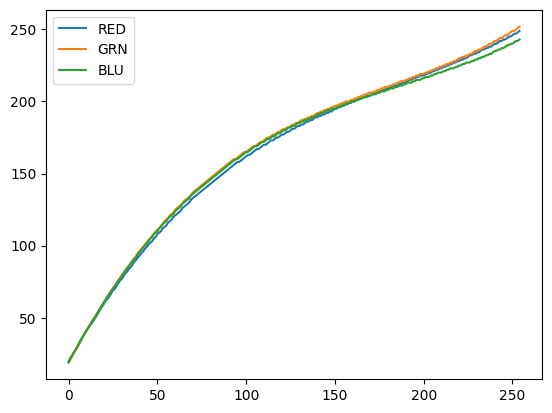

In [ ]:

file = './data/input/402-U1612A-16R-1-A_SHLF13017601_20240216235612.roi'
df = utils.read_instrument_file(file, as_dataframe=False)

f = ast.literal_eval(df['correction'])

pd.DataFrame(f['LUT']).plot()


## Reading LSIMG .jpg files

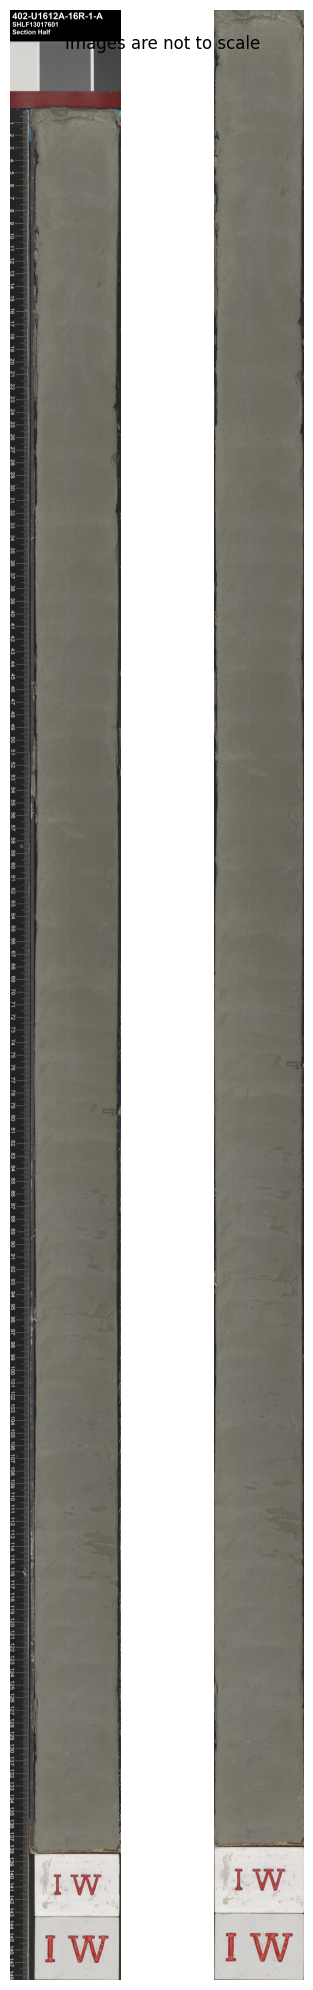

In [25]:

file1 = './data/input/402-u1612a-16r-1-a_shlf13017601_20240216235612_trim.jpg'
file2 = './data/input/402-u1612a-16r-1-a_shlf13017601_20240216235612.jpg'

fig, ax = plt.subplots(1,2,figsize=(5,20))
image = plt.imread(file2)
ax[0].imshow(image)
ax[0].axis('off')  # Turn off axis labels

image = plt.imread(file1)
ax[1].imshow(image)
ax[1].axis('off')  # Turn off axis labels
#plt.subplots_adjust(wspace=0, hspace=0)

fig.tight_layout()
fig.suptitle('Images are not to scale')
plt.show()

# Exploring LSIMG

The LUT color correction are applied to the original .tiff images. The .jpeg files are derived from the .tiff files so also take into account the LUT correction. The Brightness, Contrast and Gamma settings are only applied to the .jpeg images.

            RED  GRN  BLU
Brightness  125  125  125
Contrast     45   45   45
Gamma         1    1    1
  Polynomial Order  Value
0   RED Poly Order      3
1   GRN Poly Order      3
2   BLU Poly Order      3


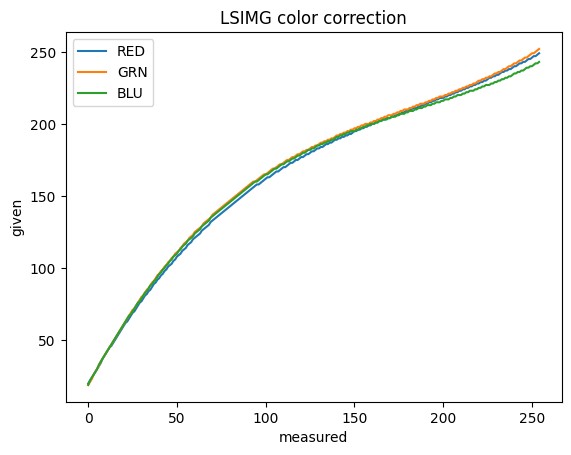

In [ ]:
# Here looking at the LUT color correction applied to each pixel

file = './data/input/402-U1612A-16R-1-A_SHLF13017601_20240216235612.roi'
d = utils.read_instrument_file(file, as_dataframe=False)
settings = ast.literal_eval(d['correction'])

# Print Brightness, Contrast, Gamma settings
print(pd.DataFrame(settings['BCG']))

# Polynomial function for calibration
print(pd.DataFrame([(key,settings[key]) for key in settings.keys() if 'Poly Order' in key], columns=['Polynomial Order', 'Value']))

pd.DataFrame(settings['LUT']).plot()
plt.title('LSIMG color correction')
plt.xlabel("measured")
plt.ylabel("given")
plt.show()
